In [1]:
! pip install pandas openpyxl seaborn matplotlib ydata-profiling



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# UNDERSTANDING DATA

### READING DATA

In [3]:
df=pd.read_excel('data.xlsx')


### HOW BIG IS THE DATA?


In [4]:
df.shape

(500, 21)

### OVERVIEW OF DATA

In [5]:
df.head()

,ID,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,...,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
0,1,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,...,87.7,26.3,30.1,35.3,11.4,189.0,9.2,12.5,0.17,22.3
1,2,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,...,88.2,25.7,20.2,35.3,11.4,180.0,8.9,12.5,0.16,19.5
2,3,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,...,77.0,22.6,29.5,37.2,13.7,148.0,10.1,14.3,0.14,30.5
3,4,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,3.8,...,77.9,23.2,29.8,46.5,17.0,143.0,8.6,11.3,0.12,16.4
4,5,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,0.4,...,80.6,23.9,29.7,42.7,15.1,236.0,19.5,12.8,0.22,24.8


### SELECTING REQUIRED COLUMNS

In [6]:
df=df[['MCV','MCH','MCHC','RDWCV','HGB']]


### DATATYPES OF COLUMNS

In [7]:
df.dtypes

MCV      float64
MCH      float64
MCHC     float64
RDWCV    float64
HGB      float64
dtype: object

### RANDOM SAMPLE OF DATA

In [8]:
df.sample(10)

,MCV,MCH,MCHC,RDWCV,HGB
82,74.5,22.4,30.1,14.2,11.5
217,86.9,28.5,32.8,12.8,16.5
414,77.4,21.7,28.1,13.6,10.2
29,86.4,26.3,30.5,12.2,9.8
421,75.1,23.9,31.8,14.8,11.5
360,72.0,22.2,31.0,15.4,9.8
33,79.9,24.4,30.5,12.6,11.5
377,74.1,27.4,31.7,12.2,13.1
432,81.2,25.1,30.9,11.7,11.6
482,78.7,25.3,32.3,12.8,1.8


### INFO ABOUT DATA

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MCV     500 non-null    float64
 1   MCH     500 non-null    float64
 2   MCHC    500 non-null    float64
 3   RDWCV   500 non-null    float64
 4   HGB     500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


### ARE THERE ANY MISSING VALUES?

In [10]:
df.isnull().sum()

MCV      0
MCH      0
MCHC     0
RDWCV    0
HGB      0
dtype: int64

### MATHEMATICAL INFO ABOUT THE DATA

In [11]:
df.describe()

,MCV,MCH,MCHC,RDWCV,HGB
count,500.000000,500.00000,500.000000,500.00000,500.000000
mean,82.181380,37.45600,30.950820,13.65478,11.740020
std,42.318848,177.87964,4.577839,6.08067,5.628807
min,-79.300000,10.90000,11.500000,8.90000,-10.000000
25%,76.575000,23.17500,29.700000,12.20000,9.900000
50%,82.800000,25.70000,30.900000,12.70000,11.500000
75%,86.500000,27.42500,31.900000,13.70000,13.100000
max,990.000000,3117.00000,92.800000,124.00000,87.100000


### ARE THERE ANY DUPLICATED VALUES?

In [12]:
df.duplicated().sum()

np.int64(38)

### ARE THERE ANY NEGATIVE VALUES?

In [13]:
(df<0).sum()

MCV      1
MCH      0
MCHC     0
RDWCV    0
HGB      1
dtype: int64

### CORRELATION BETWEEN THE COULUMNS

##### (0,1] → directly proportional correlation

##### 0 → no relationship

##### [-1,0) → inversely proportional correlation

In [14]:
df.corr()

,MCV,MCH,MCHC,RDWCV,HGB
MCV,1.000000,0.014112,0.077694,-0.039689,-0.017746
MCH,0.014112,1.000000,0.019353,-0.003771,0.001929
MCHC,0.077694,0.019353,1.000000,-0.036504,-0.112565
RDWCV,-0.039689,-0.003771,-0.036504,1.000000,-0.078176
HGB,-0.017746,0.001929,-0.112565,-0.078176,1.000000


# Exploratory Data Analysis (EDA)

## UNIVARIATE ANALYSIS

In [15]:
df.sample()

,MCV,MCH,MCHC,RDWCV,HGB
154,91.6,26.4,28.9,12.7,11.3


### Mean Corpuscular Volume (MCV)

In [16]:
df['MCV'].describe()

count    500.000000
mean      82.181380
std       42.318848
min      -79.300000
25%       76.575000
50%       82.800000
75%       86.500000
max      990.000000
Name: MCV, dtype: float64

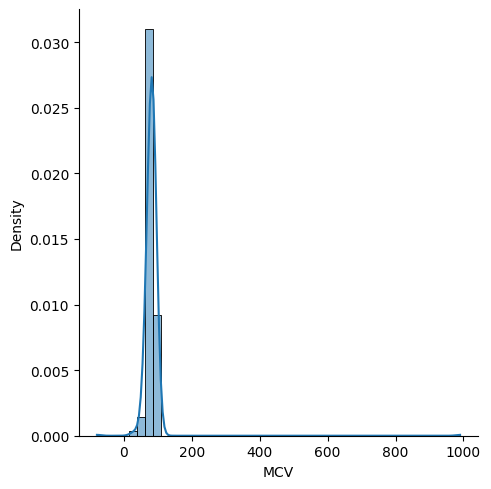

In [17]:
sns.displot(df['MCV'], kde=True,stat='density')

<Axes: xlabel='MCV'>

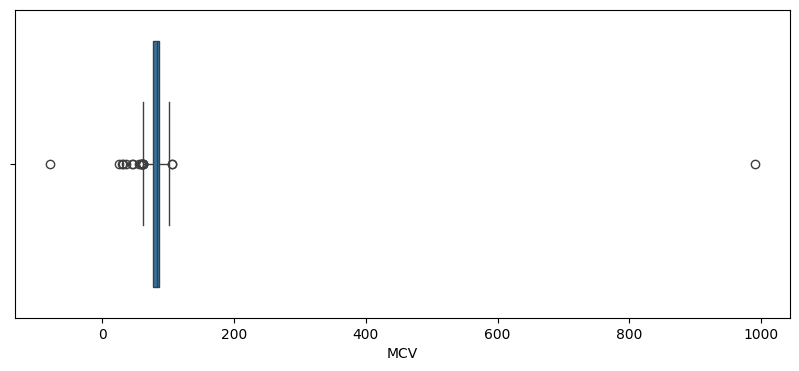

In [18]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MCV'])

### Mean Corpuscular Hemoglobin (MCH)

In [19]:
df['MCH'].describe()

count     500.00000
mean       37.45600
std       177.87964
min        10.90000
25%        23.17500
50%        25.70000
75%        27.42500
max      3117.00000
Name: MCH, dtype: float64

<Axes: xlabel='MCH', ylabel='Count'>

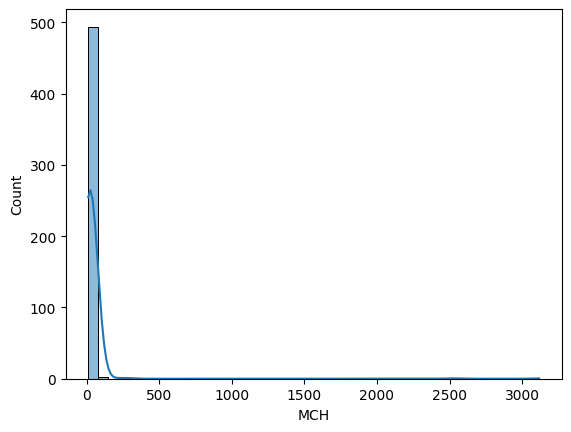

In [20]:
sns.histplot(x='MCH',data=df,kde=True)

<Axes: xlabel='MCH'>

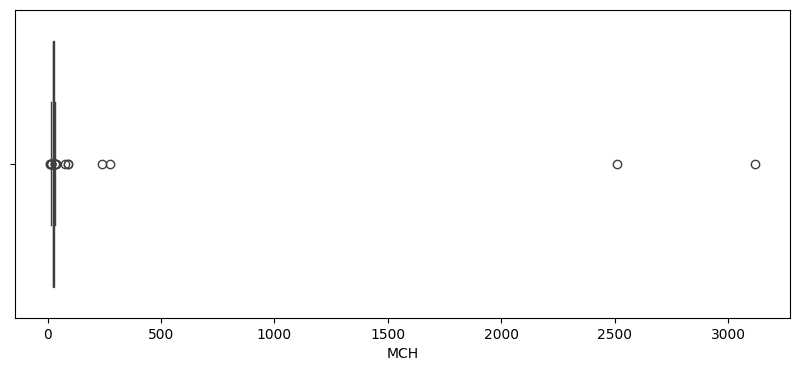

In [21]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MCH'])

### Mean Corpuscular Hemoglobin Concentration (MCHC) 

In [22]:
df['MCHC'].describe()

count    500.000000
mean      30.950820
std        4.577839
min       11.500000
25%       29.700000
50%       30.900000
75%       31.900000
max       92.800000
Name: MCHC, dtype: float64

<Axes: xlabel='MCHC', ylabel='Count'>

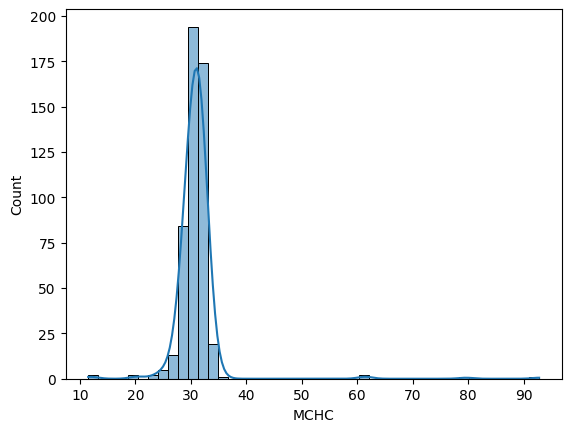

In [23]:
sns.histplot(x='MCHC',data=df,kde=True)

<Axes: xlabel='MCHC'>

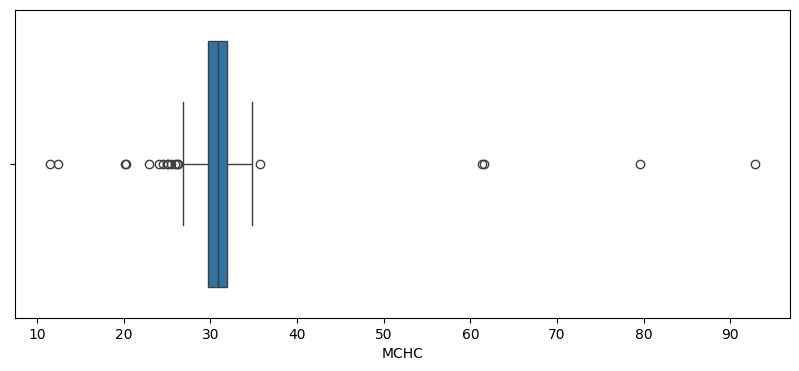

In [24]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MCHC'])

### Red Cell Distribution Width (Coefficient of Variation), RDW-CV

In [25]:
df['RDWCV'].describe()

count    500.00000
mean      13.65478
std        6.08067
min        8.90000
25%       12.20000
50%       12.70000
75%       13.70000
max      124.00000
Name: RDWCV, dtype: float64

<Axes: xlabel='RDWCV', ylabel='Count'>

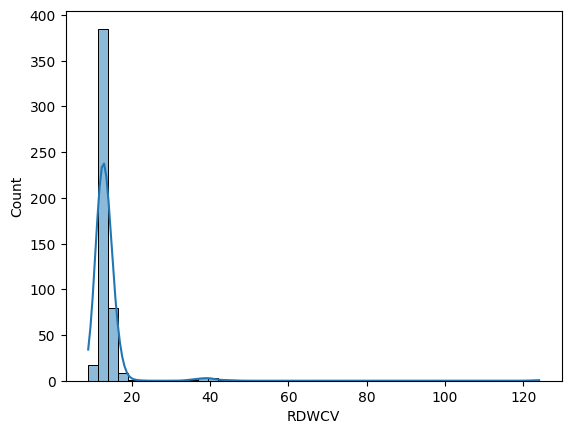

In [26]:
sns.histplot(x='RDWCV',data=df,kde=True)

<Axes: xlabel='RDWCV'>

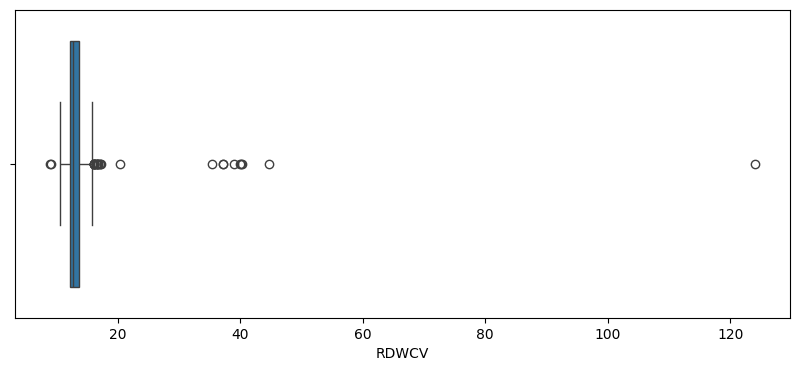

In [27]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['RDWCV'])

### Hemoglobin (HGB)

In [28]:
df['HGB'].describe()

count    500.000000
mean      11.740020
std        5.628807
min      -10.000000
25%        9.900000
50%       11.500000
75%       13.100000
max       87.100000
Name: HGB, dtype: float64

<Axes: xlabel='HGB', ylabel='Count'>

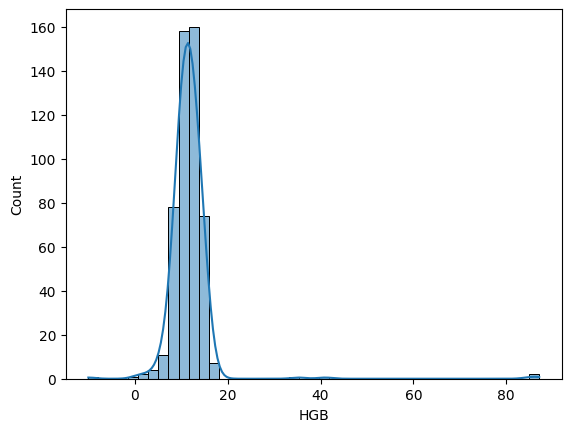

In [29]:
sns.histplot(x='HGB',data=df,kde=True)

<Axes: xlabel='HGB'>

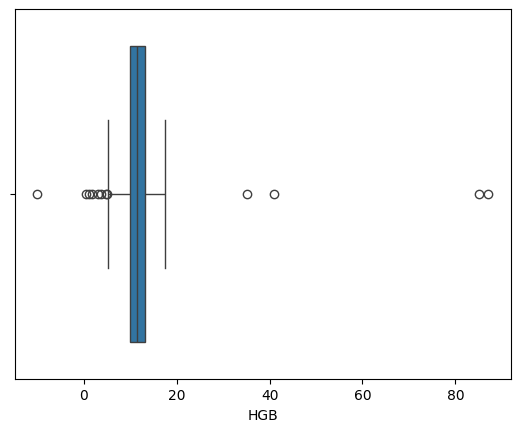

In [30]:
sns.boxplot(x=df['HGB'])

In [31]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_file("report.html")

c:\Users\jatin\anaconda3\envs\eda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 114.32it/s]


In [32]:
from IPython.display import HTML

HTML("report.html")

In [33]:
(df<0).sum()

MCV      1
MCH      0
MCHC     0
RDWCV    0
HGB      1
dtype: int64

In [34]:
df=df[df>0]

In [35]:
(df<0).sum()

MCV      0
MCH      0
MCHC     0
RDWCV    0
HGB      0
dtype: int64

In [36]:
MCV_ref=90
MCH_ref=30
MCHC_ref=34
RDW_ref=13
HGB_ref=14

In [37]:
D_MCV = np.maximum((MCV_ref - df['MCV']) / MCV_ref, 0)
D_MCH = np.maximum((MCH_ref - df['MCH']) / MCH_ref, 0)
D_MCHC = np.maximum((MCHC_ref - df['MCHC']) / MCHC_ref, 0)
D_RDW = np.maximum((df['RDWCV'] - RDW_ref) / RDW_ref, 0)
D_HGB = np.maximum((HGB_ref - df['HGB']) / HGB_ref, 0)

In [38]:
df["Severity"] = (
    0.25 * D_MCV +
    0.20 * D_MCH +
    0.20 * D_MCHC +
    0.15 * D_RDW +
    0.20 * D_HGB
)

In [39]:
df.head()

,MCV,MCH,MCHC,RDWCV,HGB,Severity
0,87.7,26.3,30.1,11.4,7.3,0.149711
1,88.2,25.7,20.2,11.4,7.3,0.210557
2,77.0,22.6,29.5,13.7,9.0,0.191421
3,77.9,23.2,29.8,17.0,3.8,0.295518
4,80.6,23.9,29.7,15.1,0.4,0.310588


In [40]:
df['Severity'].describe()

count    498.000000
mean       0.131247
std        0.107444
min        0.000000
25%        0.062366
50%        0.108478
75%        0.173168
max        1.346344
Name: Severity, dtype: float64

In [41]:
from sklearn.model_selection import train_test_split

In [47]:
X=df[['MCV','MCH','MCHC','RDWCV','HGB']]
Y=df['Severity']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [43]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((400, 5), (100, 5), (400,), (100,))

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [45]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [46]:
np.round(X_train_scaled.describe(),1)

,MCV,MCH,MCHC,RDWCV,HGB
count,399.0,400.0,400.0,400.0,399.0
mean,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0
min,-6.0,-1.2,-3.9,-0.7,-1.9
25%,-0.4,-0.2,-0.3,-0.2,-0.3
50%,0.3,-0.0,-0.0,-0.2,-0.1
75%,0.6,0.1,0.2,-0.0,0.2
max,2.8,17.9,12.2,16.9,12.4
